# Stage 2: Ранжирование кандидатов

На входе: 100 кандидатов на пользователя от SVD  
На выходе: топ-10 персональных рекомендаций от CatBoostRanker

Этапы:
1. Feature engineering
2. Обучение CatBoostRanker (YetiRank)
3. Оценка финальных метрик
4. Анализ важности признаков

In [1]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from features import build_user_features, build_item_features, build_interaction_features
from ranker import TwoStageRanker
from metrics import evaluate_all, ndcg_at_k, recall_at_k
from candidates import PopularityRecommender

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR   = Path('../data')
MODELS_DIR = Path('../models')

## 1. Загрузка данных

In [2]:
train_df   = pd.read_parquet(DATA_DIR / 'train.parquet')
val_df     = pd.read_parquet(DATA_DIR / 'val.parquet')
test_df    = pd.read_parquet(DATA_DIR / 'test.parquet')
movies     = pd.read_parquet(DATA_DIR / 'movies.parquet')
candidates = pd.read_parquet(DATA_DIR / 'candidates_for_ranking.parquet')

print(f'Train:      {len(train_df):,}')
print(f'Candidates: {len(candidates):,}')
print(f'Позитивов:  {candidates["label"].sum():,}')
print(f'Positive rate: {candidates["label"].mean():.4f}')

Train:      976,049
Candidates: 604,000
Позитивов:  4,055
Positive rate: 0.0067


## 2. Feature Engineering

In [3]:
user_features = build_user_features(train_df)
item_features = build_item_features(train_df, movies)

print('User features:')
print(user_features.head(3))
print()
print('Item features:')
print(item_features.head(3))

User features:
   user_id  user_n_ratings  user_mean_rating  user_std_rating  \
0        1              49          4.163265         0.687597   
1        2             125          3.736000         1.001161   
2        3              47          3.893617         1.005075   

   user_min_rating  user_max_rating  user_high_rate  
0              3.0              5.0        0.836735  
1              1.0              5.0        0.576000  
2              1.0              5.0        0.723404  

Item features:
   movie_id  item_n_ratings  item_mean_rating  item_std_rating  \
0         1            2030          4.146306         0.852777   
1         2             679          3.194404         0.982396   
2         3             444          2.995496         1.053845   

   item_weighted_rating  item_year  item_n_genres  \
0              4.124412     1995.0              3   
1              3.197225     1995.0              3   
2              3.019791     1995.0              2   

              

In [4]:
dataset = build_interaction_features(candidates, user_features, item_features, train_df)

print(f'Итоговый датасет: {dataset.shape}')
print(f'Признаков: {dataset.shape[1]}')
print(f'Пропуски:\n{dataset.isnull().sum()[dataset.isnull().sum() > 0]}')

Итоговый датасет: (604000, 21)
Признаков: 21
Пропуски:
user_high_rate    200
dtype: int64


## 3. Train/Val Split для ранкера

Важно: сортируем по user_id, потому что YetiRank требует,
чтобы записи одного пользователя шли подряд (group_id).

In [5]:
# Пользователи с хотя бы одним позитивом, только они полезны для обучения ранкера
users_with_positives = dataset[dataset['label'] == 1]['user_id'].unique()
dataset_filtered = dataset[dataset['user_id'].isin(users_with_positives)]

print(f'Пользователей с позитивами: {len(users_with_positives):,}')
print(f'Записей после фильтрации:   {len(dataset_filtered):,}')

# Split: 80% пользователей в train, 20% в val
np.random.seed(42)
train_users = np.random.choice(
    users_with_positives,
    size=int(len(users_with_positives) * 0.8),
    replace=False
)
val_users = np.setdiff1d(users_with_positives, train_users)

train_rank = dataset_filtered[dataset_filtered['user_id'].isin(train_users)].sort_values('user_id')
val_rank   = dataset_filtered[dataset_filtered['user_id'].isin(val_users)].sort_values('user_id')

print(f'\nTrain ranker: {len(train_rank):,} записей, {len(train_users):,} пользователей')
print(f'Val ranker:   {len(val_rank):,} записей, {len(val_users):,} пользователей')

Пользователей с позитивами: 2,766
Записей после фильтрации:   276,600

Train ranker: 221,200 записей, 2,212 пользователей
Val ranker:   55,400 записей, 554 пользователей


## 4. Обучение CatBoostRanker

In [6]:
ranker = TwoStageRanker(
    iterations=500,
    learning_rate=0.05,
    depth=6,
)

ranker.fit(train_rank, val_df=val_rank)
ranker.save(MODELS_DIR / 'ranker.pkl')

0:	test: 0.0944237	best: 0.0944237 (0)	total: 120ms	remaining: 59.7s


100:	test: 0.2360305	best: 0.2365595 (83)	total: 6.07s	remaining: 24s
200:	test: 0.2337630	best: 0.2382664 (124)	total: 10.7s	remaining: 16s
300:	test: 0.2371759	best: 0.2384607 (265)	total: 15.2s	remaining: 10.1s
400:	test: 0.2291084	best: 0.2384607 (265)	total: 19.7s	remaining: 4.87s
499:	test: 0.2230810	best: 0.2384607 (265)	total: 24.3s	remaining: 0us

bestTest = 0.2384607403
bestIteration = 265

Shrink model to first 266 iterations.


## 5. Оценка метрик

Сравниваем три варианта:
- **Popularity** — бейзлайн (Stage 1)
- **SVD-only** — Stage 1 без ранжирования, топ-10 по candidate_score
- **Two-Stage** — SVD + CatBoostRanker

In [7]:
# Ground truth для финальной оценки - val_df (факт просмотра)
ground_truth = val_df[['user_id', 'movie_id']].copy()
eval_users   = ground_truth['user_id'].unique().tolist()

# Two-Stage рекомендации
recs_two_stage = ranker.recommend(dataset, top_k=10)

# SVD топ-10 напрямую (без ранкера)
recs_svd_top10 = (
    candidates.sort_values(['user_id', 'candidate_score'], ascending=[True, False])
    .groupby('user_id')
    .head(10)
    .assign(rank=lambda df: df.groupby('user_id')['candidate_score']
            .rank(ascending=False, method='first').astype(int))
    [['user_id', 'movie_id', 'rank']]
)

# Загружаем popularity модель из Stage 1
pop = PopularityRecommender.load(MODELS_DIR / 'popularity.pkl')
recs_pop = pop.recommend(eval_users, top_k=10)

print('Two-Stage metrics:')
print(evaluate_all(recs_two_stage, ground_truth, k_values=[5, 10]))

print('\nSVD-only (top-10) metrics:')
print(evaluate_all(recs_svd_top10, ground_truth, k_values=[5, 10]))

print('\nPopularity (baseline) metrics:')
print(evaluate_all(recs_pop, ground_truth, k_values=[5, 10]))

Two-Stage metrics:
               @5     @10
Precision  0.0336  0.0248
Recall     0.0560  0.0826
NDCG       0.0533  0.0653
HitRate    0.1472  0.2071
MRR        0.0890  0.0969

SVD-only (top-10) metrics:
               @5     @10
Precision  0.0198  0.0163
Recall     0.0329  0.0545
NDCG       0.0295  0.0392
HitRate    0.0894  0.1406
MRR        0.0483  0.0550

Popularity (baseline) metrics:
               @5     @10
Precision  0.0067  0.0063
Recall     0.0111  0.0209
NDCG       0.0097  0.0140
HitRate    0.0306  0.0553
MRR        0.0157  0.0188


HitRate@10 = 0.207. У 20.7% пользователей хотя бы один из топ-10 фильмов совпал с тем, что они реально посмотрели. У SVD-only только 14.1%.

NDCG@10 = 0.065. Нужный фильм не только попадает в топ-10, но и стоит ближе к началу списка. Рост с 0.039 говорит, что ранкер умеет поднимать релевантное выше.

MRR@10 = 0.097. В среднем нужный фильм стоит на позиции 1/0.090 = 10. У SVD-only 1/0.055 = 18. Ранкер существенно поднимает релевантное выше по списку.

Recall@10 = 0.082. Из всех релевантных фильмов в val система находит 8.2%. Ограничено сверху Recall Stage 1 = 22.7%.

Popularity baseline ожидаемо слабее всех: HitRate@10 = 0.055, NDCG@10 = 0.014.
Рекомендация одних и тех же популярных фильмов всем пользователям не учитывает
индивидуальные предпочтения.

## 6. Важность признаков

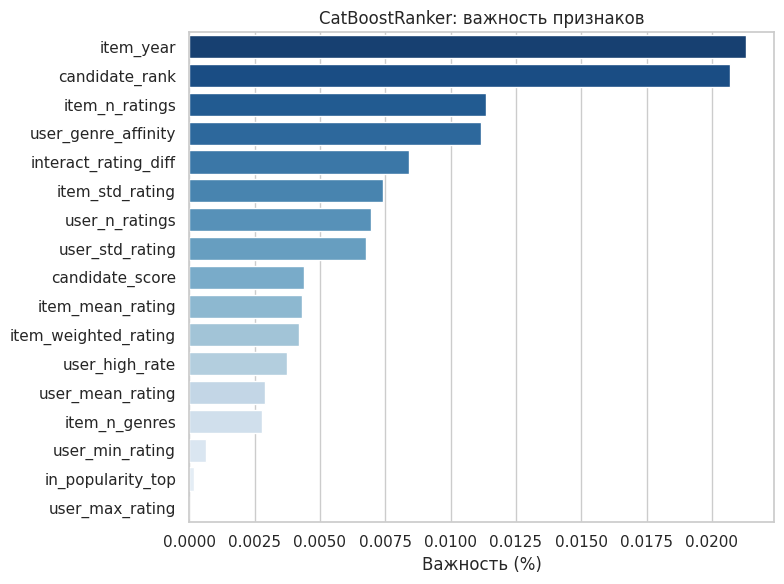

             feature  importance
           item_year    0.021308
      candidate_rank    0.020682
      item_n_ratings    0.011360
 user_genre_affinity    0.011156
interact_rating_diff    0.008413
     item_std_rating    0.007417
      user_n_ratings    0.006939
     user_std_rating    0.006745
     candidate_score    0.004399
    item_mean_rating    0.004324
item_weighted_rating    0.004201
      user_high_rate    0.003725
    user_mean_rating    0.002909
       item_n_genres    0.002771
     user_min_rating    0.000640
   in_popularity_top    0.000160
     user_max_rating    0.000000


In [8]:
fi = ranker.get_feature_importance(train_rank)
plt.figure(figsize=(8, 6))
sns.barplot(data=fi, x='importance', y='feature', palette='Blues_r')
plt.xlabel('Важность (%)')
plt.ylabel('')
plt.title('CatBoostRanker: важность признаков')
plt.tight_layout()
plt.savefig(DATA_DIR / 'feature_importance.png', bbox_inches='tight')
plt.show()

print(fi.to_string(index=False))

## 7. Пример рекомендаций

In [9]:
# Смотрим рекомендации для случайного пользователя
sample_user = eval_users[42]

user_recs = recs_two_stage[recs_two_stage['user_id'] == sample_user]
user_recs = user_recs.merge(movies[['movie_id', 'title', 'genres']], on='movie_id')

print(f'Рекомендации для пользователя {sample_user}:')
print(user_recs[['rank', 'title', 'genres', 'score']].to_string(index=False))

# Что пользователь смотрел в val
user_val = val_df[val_df['user_id'] == sample_user].merge(
    movies[['movie_id', 'title']], on='movie_id'
)
print(f'\nВ val пользователь смотрел: {user_val["title"].values}')

Рекомендации для пользователя 43:
 rank                           title                         genres    score
    1          American Beauty (1999)                   Comedy|Drama 1.491213
    2              Toy Story 2 (1999)    Animation|Children's|Comedy 1.306975
    3                Toy Story (1995)    Animation|Children's|Comedy 1.177633
    4            Bug's Life, A (1998)    Animation|Children's|Comedy 1.127817
    5             Ghostbusters (1984)                  Comedy|Horror 1.053333
    6             Men in Black (1997) Action|Adventure|Comedy|Sci-Fi 1.024819
    7            High Fidelity (2000)                         Comedy 0.921092
    8 Ferris Bueller's Day Off (1986)                         Comedy 0.907335
    9                     Babe (1995)        Children's|Comedy|Drama 0.903492
   10            Almost Famous (2000)                   Comedy|Drama 0.897206

В val пользователь смотрел: ['Toy Story 2 (1999)' 'Thomas Crown Affair, The (1999)' 'X-Men (2000)']
